In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import learning_curve
np.random.seed(42)

In [15]:
# Hämta MNIST-datasetet
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# Definiera X och y
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Spara data och mål som NumPy-filer
np.save("X_mnist.npy",X)
np.save("y_mnist.npy", y)

# Kontrollera om några bilder är tomma (alla pixelvärden = 0)
empty_indices = np.where(X.sum(axis=1) == 0)[0]

# Skriv ut information om de tomma bilderna
print(f"Antal tomma bilder: {len(empty_indices)}")
print(f"Index för tomma bilder: {empty_indices}")

X shape: (70000, 784)
y shape: (70000,)
Antal tomma bilder: 0
Index för tomma bilder: []


In [3]:
# Ladda sparade NumPy-filer
def load_mnist_data():
    X = np.load("X_mnist.npy")  # Pixeldata
    y = np.load("y_mnist.npy").astype(np.uint8)  # Etiketter som uint8
    print(f"Data laddad: X shape = {X.shape}, y shape = {y.shape}")
    return X, y  # Returnera data och mål

# Använd funktionen för att ladda data
X, y = load_mnist_data()

Data laddad: X shape = (70000, 784), y shape = (70000,)


In [16]:
# Fördela data i tränings- och testset så att testdatan är 35% av den totala datan
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.4285, random_state=42)

# Ange antalet träningsobservationer som ska vara 25 000
train_size = 25000

# Fördela tränings- och valideringsdatan så att valideringsdatan utgör resterande del
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=train_size, random_state=42)

# Kontrollera storleken på tränings- och valideringsdatan
print(f'Train data shape: {X_train.shape}, {y_train.shape}')
print(f'Validation data shape: {X_val.shape}, {y_val.shape}')
print(f'Test data shape: {X_test.shape}, {y_test.shape}')

Train data shape: (25000, 784), (25000,)
Validation data shape: (15005, 784), (15005,)
Test data shape: (29995, 784), (29995,)


In [17]:
# Skapa en pipeline för MultinomialNB  (basline version)
nb = Pipeline([
    ('scaler', MinMaxScaler()), 
    ('model', MultinomialNB())
])

# Träna pipelinen på träningsdata
nb.fit(X_train, y_train)

# Spara pipelinen
joblib.dump(nb, 'nb_trained.pkl')

score = nb.score(X_val, y_val)

print('Modellen är tränad och sparad')
print("MultinomialNB:", score)

Modellen är tränad och sparad
MultinomialNB: 0.8261912695768078


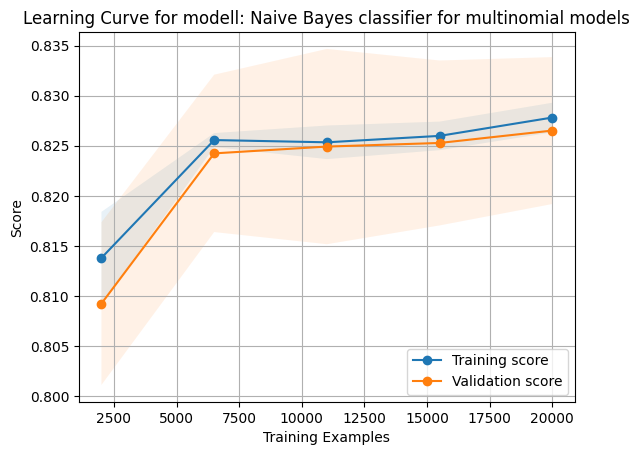

In [18]:
# Ladda den sparade pipelinen med modellen
nb = joblib.load('nb_trained.pkl')

# Funktion för att plotta inlärningskurva
def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=5, n_jobs=-1)
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.title(title)
    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    plt.show()

    # Plotta inlärningskurva för den laddade pipelinen med modellen
plot_learning_curve(nb, 'Learning Curve for modell: Naive Bayes classifier for multinomial models', X_train, y_train)

In [13]:
# Ladda in tränad modell 
nb = joblib.load('nb_trained.pkl')

# Gör prediktioner på valideringsdata med Naive Bayes-pipelinen
y_val_pred = nb.predict(X_val)

# Utvärdera modellens prestanda
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, average='macro')
recall = recall_score(y_val, y_val_pred, average='macro')
f1 = f1_score(y_val, y_val_pred, average='weighted')

# Samla resultaten
results = [{
    "Model": "Naive Bayes",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}]

# Spara resultaten
joblib.dump(results, 'nb_result.pkl')

# Konvertera resultaten till en DataFrame och visa dem
results = pd.DataFrame(results)
results

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.826191,0.834102,0.823759,0.827396


In [16]:
# Ladda den sparade modellen
nb = joblib.load('nb_trained.pkl')

# Definiera scorer
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# Beräkna cross-validation scores
cv_results = cross_validate(nb, X_train, y_train, cv=5, scoring=scoring)

# Skapa en lista med resultaten
results = []
for fold in range(5):
    results.append({
        'Fold': fold,
        'Accuracy': cv_results['test_accuracy'][fold],
        'Precision': cv_results['test_precision'][fold],
        'Recall': cv_results['test_recall'][fold],
        'F1-score': cv_results['test_f1'][fold]
    })

# Konvertera listan till en DataFrame
results = pd.DataFrame(results)

# Spara DataFrame med joblib
joblib.dump(results, 'cross_validation_results.pkl')

# Visa DataFrame
results

,Fold,Accuracy,Precision,Recall,F1-score
0,0,0.8212,0.830287,0.818530,0.820835
1,1,0.8152,0.824979,0.812290,0.815152
2,2,0.8356,0.842024,0.832058,0.833043
3,3,0.8294,0.836089,0.826371,0.828071
4,4,0.8312,0.838601,0.828417,0.830135


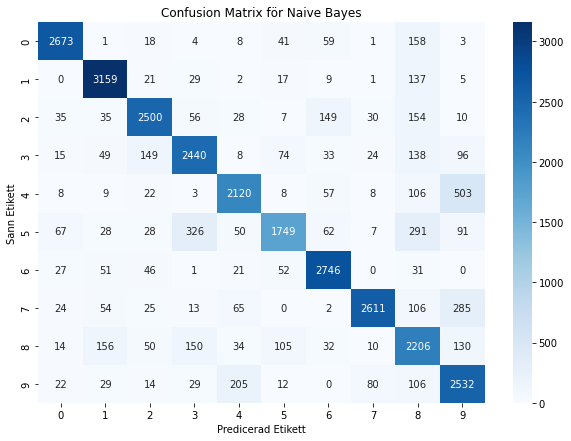

In [17]:
# Ladda tränade NB modell 
nb = joblib.load('nb_trained.pkl')

# Generera prediktioner på testdatan
y_test_pred = nb.predict(X_test)

# Skapa Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Visualisera Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix för Naive Bayes')
plt.xlabel('Predicerad Etikett')
plt.ylabel('Sann Etikett')
plt.show()

I confusion Matris har modellen störst andel problem med att särskilja sifforna 4 och 9, redovisas nedan.

In [18]:
cm = confusion_matrix(y_test, y_test_pred)
print("Misstag mellan 4 och 9:", cm[4, 9])
print("Misstag mellan 9 och 4:", cm[9, 4])
print('Största prediktionsfelet:',503/25000)

Misstag mellan 4 och 9: 503
Misstag mellan 9 och 4: 205
Största prediktionsfelet: 0.02012


En visualisering, en bild på ritat siffra, dess faktiskt värde, och 
modellens prediktion.

Visualisering av modellens prediktioner på 5 siffor, rätt tal och gissat tal


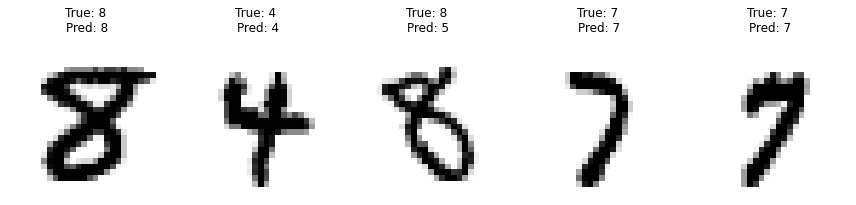

In [21]:
# Ladda den sparade modellen
nb = joblib.load('nb_trained.pkl')

def plot_predictions(images, true_labels, predicted_labels, n=5):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='binary')
        plt.title(f"True: {true_labels[i]} \nPred: {predicted_labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Välj exempeldata
examples = 5
X_example = X_test[:examples]
y_true_example = y_test[:examples]

# Gör prediktioner med modellen
y_pred_example = nb.predict(X_example)

# Visa bilderna och prediktionerna
print("Visualisering av modellens prediktioner på 5 siffor, rätt tal och gissat tal")
plot_predictions(X_example, y_true_example, y_pred_example)